In [1]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm

import dbof.dataset_creation.zarr_dataset_global as zarr_dataset
import dbof.io.filesystems as filesystems

# Load GLOBAL DBOF

## Dataset access config

For convenience the parameters used in accessing the dataset can be stored in config files under ```configs/data_access/```.
These values must match the run configurations.

Example config:
```
data_access:
  s3_endpoint: "https://s3-west.nrp-nautilus.io"
  bucket: "llc"
  folder: "native_grid_dbof_training_data"
  run_id: "year_4x150"
```

If the user prefers, these values can also simply be hardcoded when using the package.

In [2]:
path_to_config = "../../configs/data_access/global.yaml"
with open(path_to_config) as f:
    data_cfg = yaml.safe_load(f)["data_access"]

bucket = data_cfg["bucket"]
folder = data_cfg["folder"]
s3_endpoint = data_cfg["s3_endpoint"]
feature_channels = data_cfg["feature_channels"]
run_id = data_cfg["run_id"]  # update configs/data_access/global.yaml to change this

# User can also simply do
# bucket = "bucket"
# folder = "folder"
# run_id = "my_run_id"

In [3]:
# Build our file system for accessing remote files
fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

# Load the data 

In [4]:
# This reader class will allow easy access to the remotely stored data

reader = zarr_dataset.GlobalZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name="dataset_creation.zarr",
    fs=fs
)

### Plot global maps

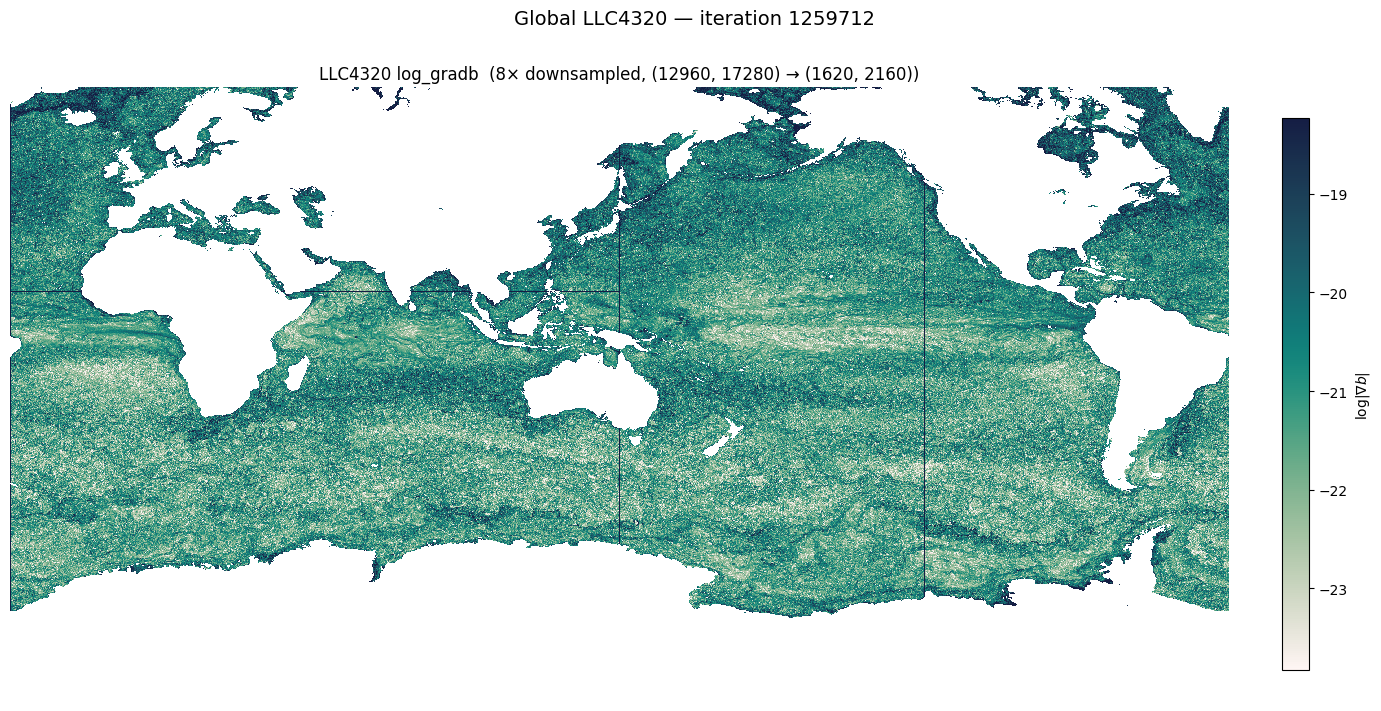

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cmo

# ── Choose one channel ─────────────────────────────────────────────────────────
target = "log_gradb"
DS     = 8          # global-overview downsample factor

channels = reader.channel_names
try:
    i = channels.index(target)
except ValueError:
    raise ValueError(f"Channel '{target}' not found. Available: {channels}")

# ── Load just ONE channel, then downsample ─────────────────────────────────────
# get_channel_snapshot() loads a single (H, W) chunk instead of all C channels.
arr_full = reader.get_channel_snapshot(0, i)   # (H, W) numpy array
arr_plot = arr_full[::DS, ::DS]                # downsample for fast rendering

# ── Percentiles ────────────────────────────────────────────────────────────────
finite = arr_plot[np.isfinite(arr_plot)]
vmin, vmax = np.nanpercentile(finite, [1, 99])

# ── Plot ───────────────────────────────────────────────────────────────────────
# origin='lower' → row 0 (southern latitudes) at bottom: north-up orientation
cmap  = cmo.tempo
label = r'log$|\nabla b|$'

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(arr_plot, cmap=cmap, vmin=vmin, vmax=vmax,
               origin='lower', aspect='auto', interpolation='nearest')
ax.set_title(f'LLC4320 {target}  ({DS}× downsampled, {arr_full.shape} → {arr_plot.shape})',
             fontsize=12)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.9, label=label)
plt.suptitle(f'Global LLC4320 — iteration {reader.time[0]}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


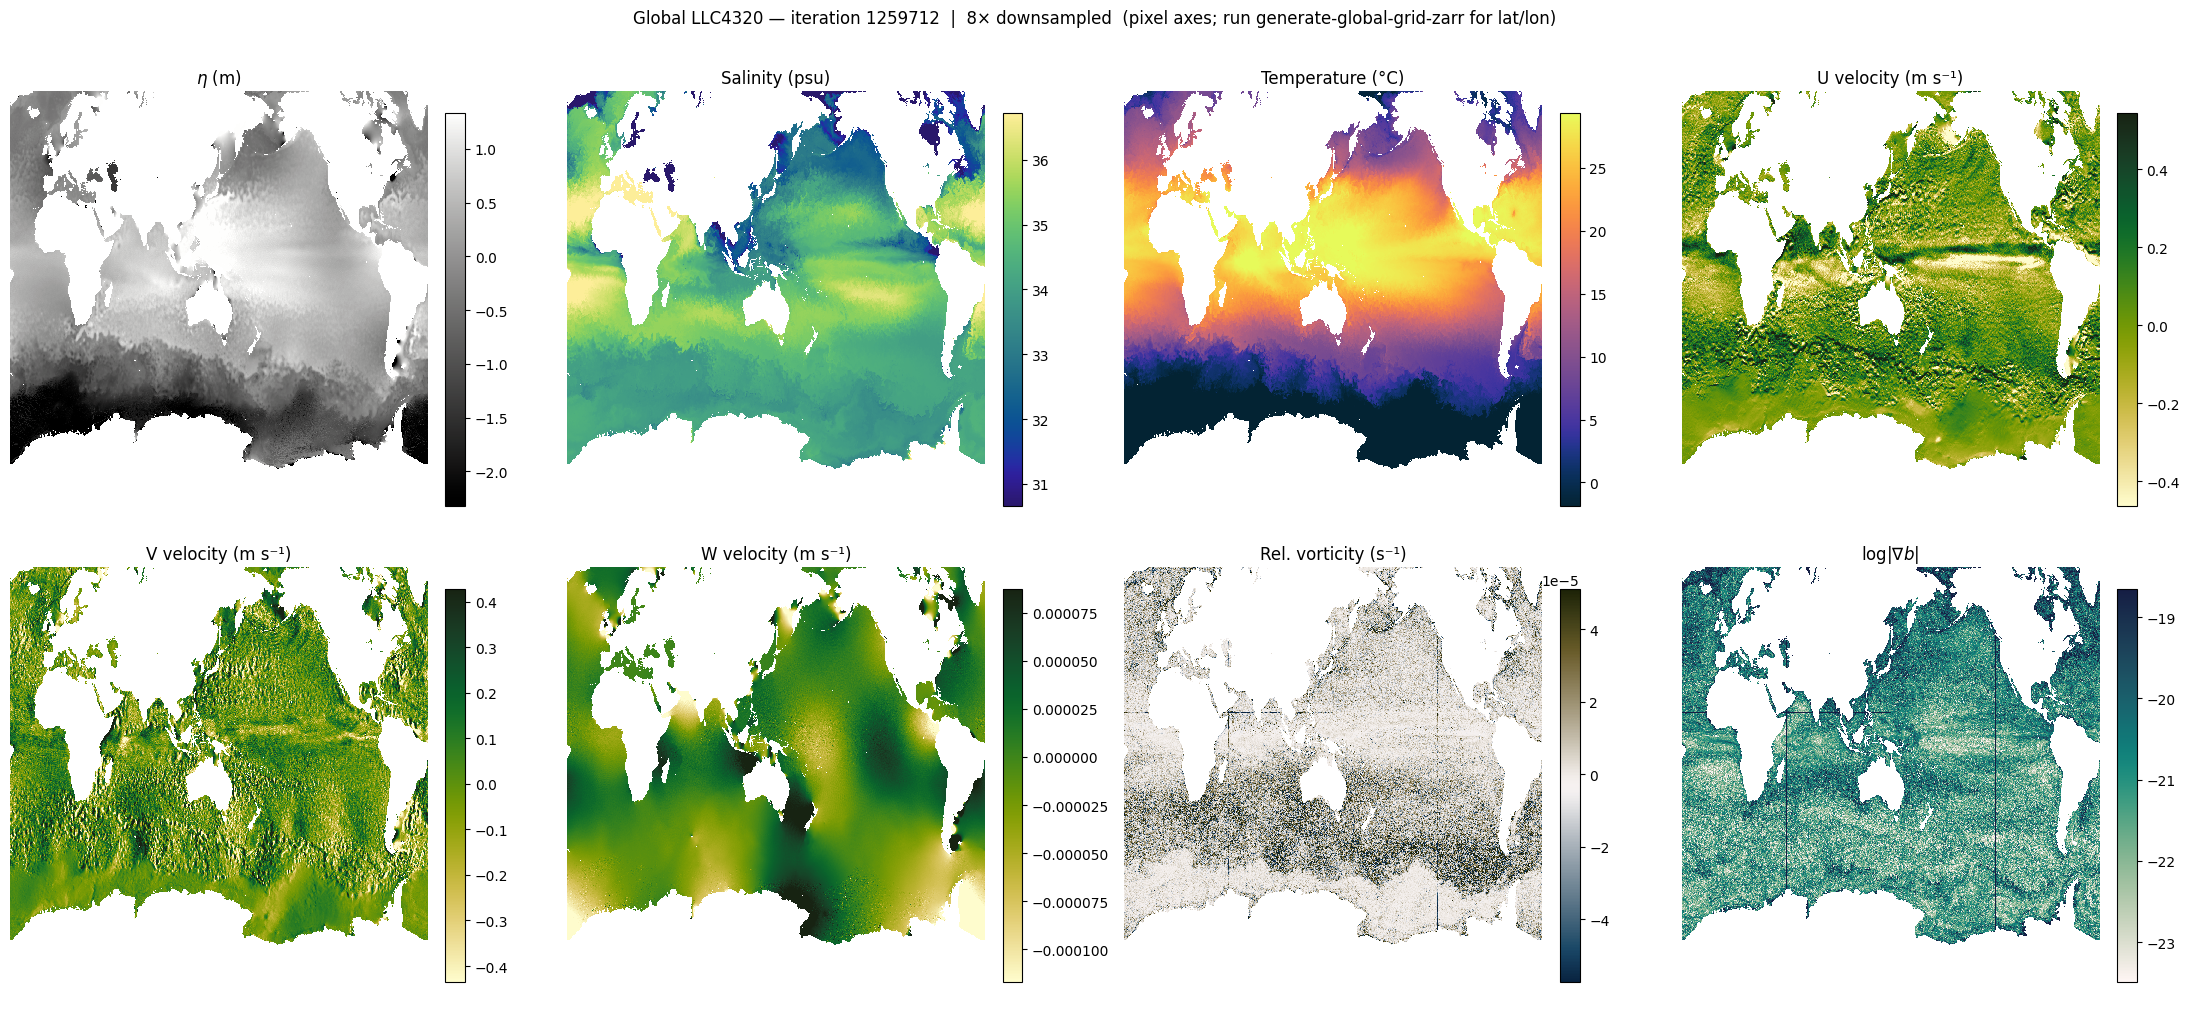

In [6]:
import cmocean.cm as cmo
import numpy as np

DS = 8   # global-overview downsample (8× → ~1/64 of pixels per channel)

# ── Colormap / label config ────────────────────────────────────────────────────
CMAP_CFG = {
    'Eta':                ('gray',    r'$\eta$ (m)'),
    'Salt':               ('haline',  'Salinity (psu)'),
    'Theta':              ('thermal', 'Temperature (°C)'),
    'U':                  ('speed',   'U velocity (m s⁻¹)'),
    'V':                  ('speed',   'V velocity (m s⁻¹)'),
    'W':                  ('speed',   'W velocity (m s⁻¹)'),
    'relative_vorticity': ('diff',    'Rel. vorticity (s⁻¹)'),
    'log_gradb':          ('tempo',   r'log$|\nabla b|$'),
}
channel_order = ['Eta', 'Salt', 'Theta', 'U', 'V', 'W', 'relative_vorticity', 'log_gradb']
channels = reader.channel_names

# ── 8-panel global overview ────────────────────────────────────────────────────
# Load one channel at a time (get_channel_snapshot loads 1 chunk vs C chunks).
# origin='lower' → southern latitudes (low row index) at the bottom → north-up.
ncols, nrows = 4, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 5))
axes = axes.flatten()

for ax, ch in zip(axes, channel_order):
    arr = reader.get_channel_snapshot(0, ch)[::DS, ::DS]
    cmap_name, label = CMAP_CFG[ch]
    cmap = getattr(cmo, cmap_name)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        ax.set_visible(False)
        continue
    vmin, vmax = np.nanpercentile(finite, [2, 98])
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax,
                   origin='lower', aspect='auto', interpolation='nearest')
    ax.set_title(label, fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.9)

for ax in axes[len(channel_order):]:
    ax.set_visible(False)

plt.suptitle(
    f'Global LLC4320 — iteration {reader.time[0]}  |  '
    f'{DS}× downsampled  (pixel axes; run generate-global-grid-zarr for lat/lon)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()


### Plot log_gradb in a specified location.

#### About lat/lon coordinates

The Zarr store uses integer **pixel indices** `(y, x)` — there are no geographic coordinates baked in.  
To select a region by actual **(lat, lon)** you need the `XC`/`YC` grid arrays, which are 2D fields  
(shape 12960 × 17280) giving the geographic coordinate of every pixel.

**Generate them once** with:
```bash
generate-global-grid --output /path/to/llc4320_grid.nc
```
Set `GRID_NC_PATH` below to that path and `USE_LATLON = True`.  
Until then, set `USE_LATLON = False` and specify the region in pixel coordinates.

In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# USER SETTINGS — edit these to choose your region
# ════════════════════════════════════════════════════════════════════════════════

USE_LATLON = False          # ← set True once you have run generate-global-grid-zarr

# ── Option A: pixel coordinates (always available) ────────────────────────────
# (0,0) is top-left of the rectangular image.
# Full image is 12960 rows (y) × 17280 cols (x).
Y_CENTER_PIX  = 4500        # row index of region centre
X_CENTER_PIX  = 5500        # col index of region centre
HALF_H_PIX    = 600         # half-height in pixels
HALF_W_PIX    = 900         # half-width  in pixels

# ── Option B: lat/lon coordinates (requires running generate-global-grid-zarr) ─
LAT_CENTER    =  36.0       # degrees north
LON_CENTER    = -72.0       # degrees east  (use negative for west)
GRID_DATASET  = "llc4320_grid.zarr"   # must match --dataset-name used when writing
HALF_H_KM     = 1000        # approximate half-height in km
HALF_W_KM     = 2000        # approximate half-width  in km

# ════════════════════════════════════════════════════════════════════════════════

H, W = reader.rectangular_shape   # (12960, 17280)

if USE_LATLON:
    import dbof.dataset_creation.zarr_grid_global as zarr_grid

    grid_reader = zarr_grid.GlobalGridZarrReader(
        bucket=bucket,
        folder=folder,
        dataset_name=GRID_DATASET,
        fs=fs,
    )
    XC = grid_reader.lon   # (H, W) — longitude of each pixel
    YC = grid_reader.lat   # (H, W) — latitude  of each pixel
    print(grid_reader)

    # Normalise input longitude to match XC convention (may be 0–360 or −180–180)
    lon_q = LON_CENTER % 360 if XC.max() > 180 else LON_CENTER

    # Find the pixel whose (lat, lon) is closest to the requested centre
    dist = np.sqrt((XC - lon_q) ** 2 + (YC - LAT_CENTER) ** 2)
    cy, cx = np.unravel_index(np.nanargmin(dist), dist.shape)
    print(f"Nearest pixel to ({LAT_CENTER}°N, {LON_CENTER}°E): y={cy}, x={cx}")

    # LLC4320 native resolution ≈ 1/48° ≈ 2.3 km at mid-latitudes
    KM_PER_PIX  = 2.3
    HALF_H_PIX  = int(HALF_H_KM / KM_PER_PIX)
    HALF_W_PIX  = int(HALF_W_KM / KM_PER_PIX)
    Y_CENTER_PIX, X_CENTER_PIX = cy, cx

# Clamp bounding box to image extent
y0 = max(0, Y_CENTER_PIX - HALF_H_PIX)
y1 = min(H, Y_CENTER_PIX + HALF_H_PIX)
x0 = max(0, X_CENTER_PIX - HALF_W_PIX)
x1 = min(W, X_CENTER_PIX + HALF_W_PIX)

print(f"Selected region: rows [{y0}:{y1}], cols [{x0}:{x1}]  →  {y1-y0} × {x1-x0} pixels")

Selected region: rows [3900:5100], cols [4600:6400]  →  1200 × 1800 pixels


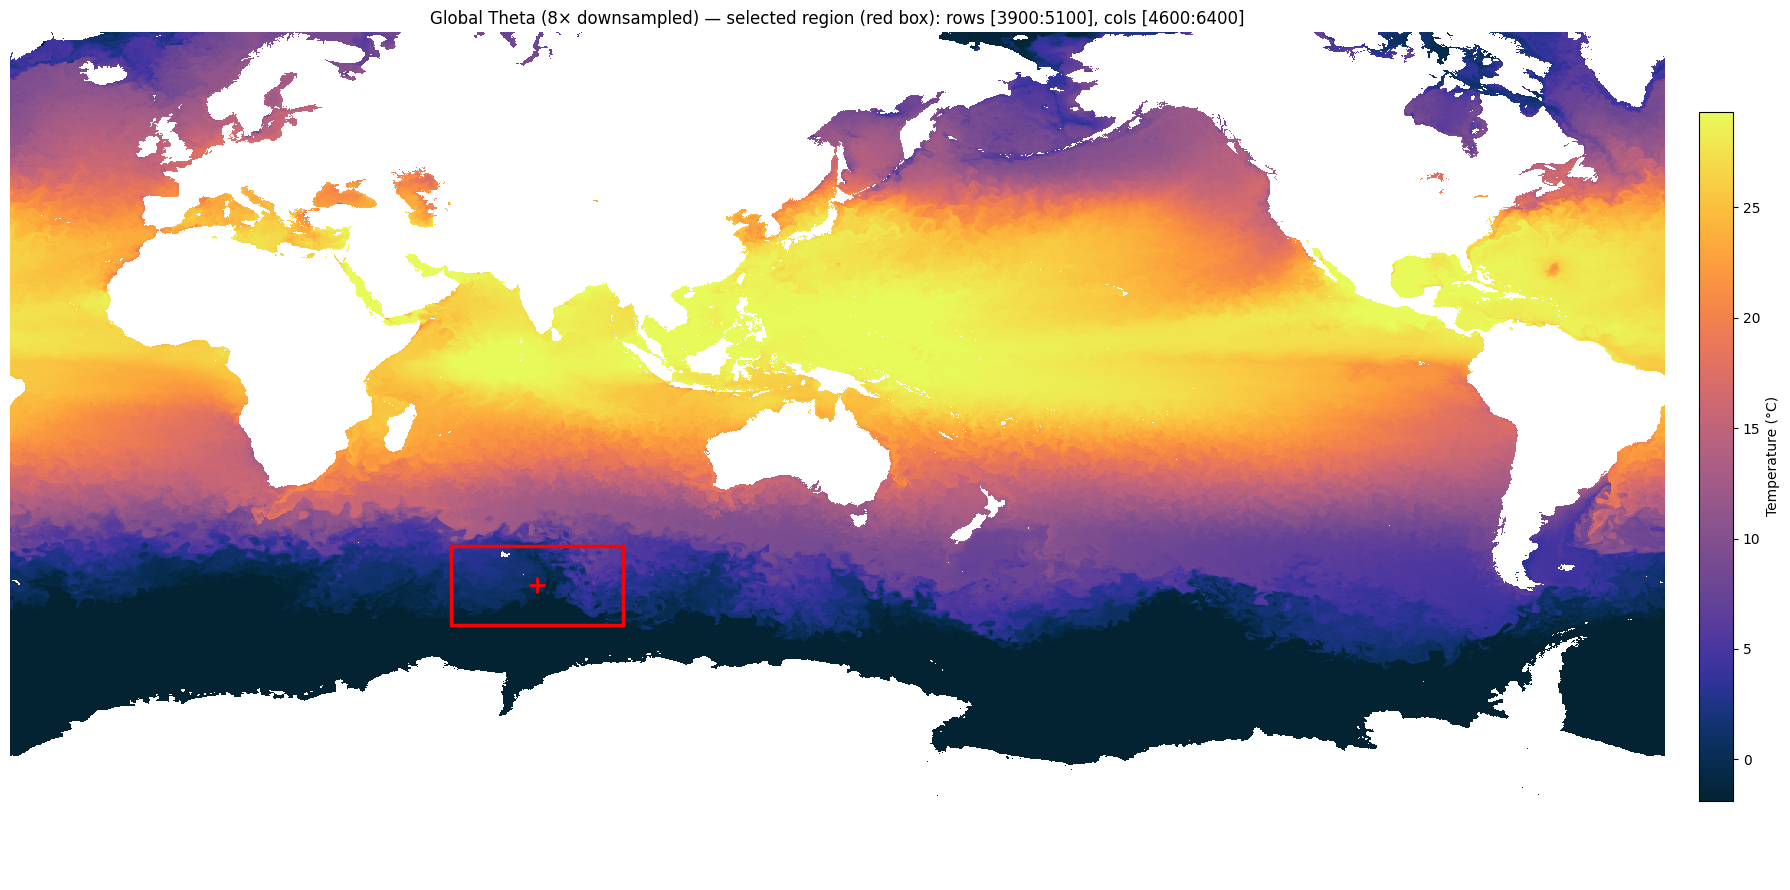

In [8]:
import cmocean.cm as cmo
import numpy as np
from matplotlib.patches import Rectangle

# ── Global background (Theta, downsampled) ────────────────────────────────────
DS_BG = 8
theta_plot = reader.get_channel_snapshot(0, 'Theta')[::DS_BG, ::DS_BG]
vmin_t, vmax_t = np.nanpercentile(theta_plot[np.isfinite(theta_plot)], [2, 98])

fig, ax = plt.subplots(figsize=(18, 9))
im = ax.imshow(theta_plot, cmap=cmo.thermal, vmin=vmin_t, vmax=vmax_t,
               origin='lower', aspect='auto', interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label='Temperature (°C)')

# ── Overlay selection box (scale pixel coords to downsampled image space) ─────
rect = Rectangle(
    (x0 / DS_BG, y0 / DS_BG),
    (x1 - x0) / DS_BG, (y1 - y0) / DS_BG,
    linewidth=2.5, edgecolor='red', facecolor='none', zorder=5
)
ax.add_patch(rect)
ax.plot(X_CENTER_PIX / DS_BG, Y_CENTER_PIX / DS_BG,
        'r+', markersize=12, markeredgewidth=2, zorder=6)

ax.set_title(
    f'Global Theta ({DS_BG}× downsampled) — selected region (red box): '
    f'rows [{y0}:{y1}], cols [{x0}:{x1}]',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.show()


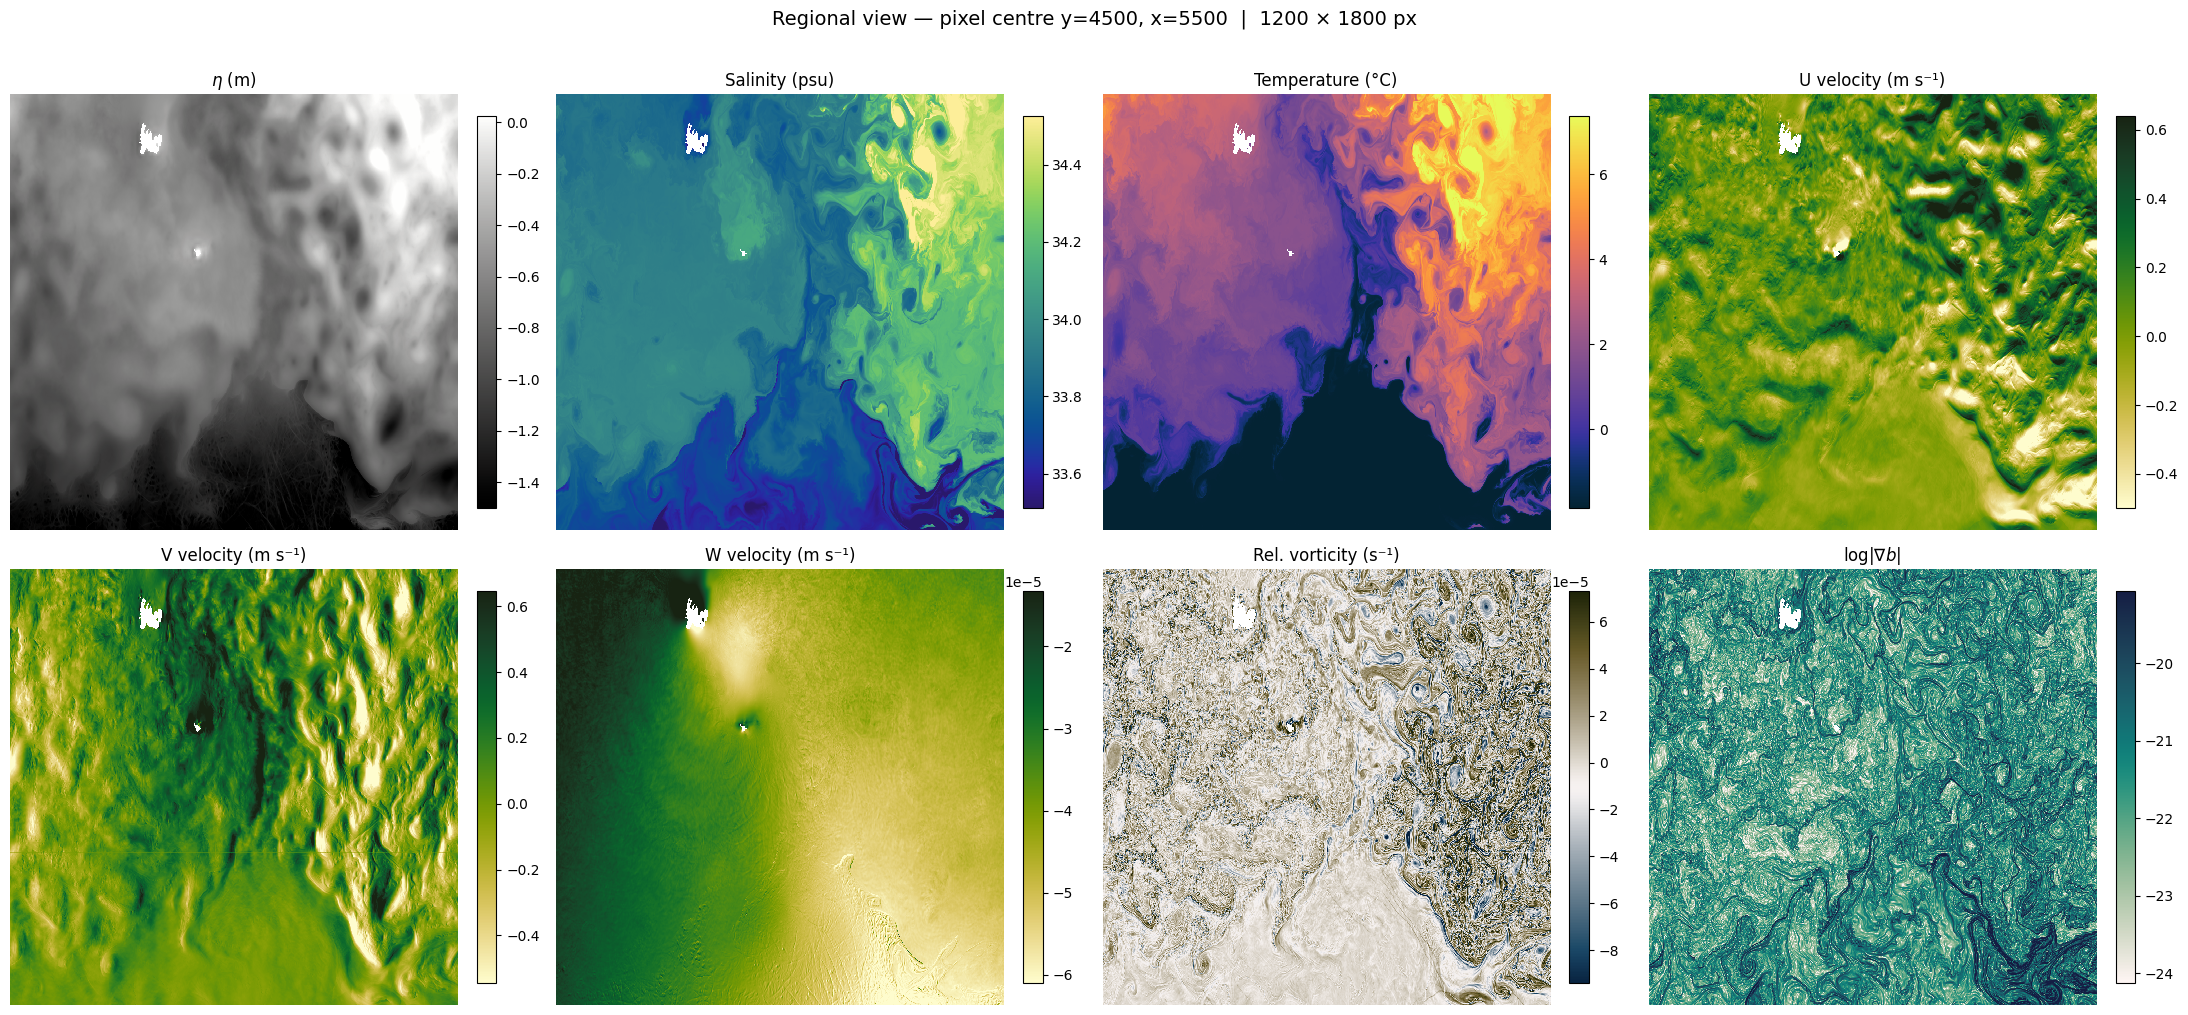

In [9]:
import numpy as np

# ── Regional subplots — load each channel slice individually ──────────────────
# Each get_channel_snapshot() call downloads 1 full (H,W) chunk from S3, then
# the [y0:y1, x0:x1] slice is extracted in Python.  Only one channel is in RAM
# at a time; the regional slice is typically small (seconds to render).
ncols, nrows = 4, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 5))
axes = axes.flatten()

for ax, ch in zip(axes, channel_order):
    arr = reader.get_channel_snapshot(0, ch)[y0:y1, x0:x1]
    cmap_name, label = CMAP_CFG[ch]
    cmap = getattr(cmo, cmap_name)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        ax.set_visible(False)
        continue
    vmin, vmax = np.nanpercentile(finite, [1, 99])
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax,
                   origin='lower', aspect='auto', interpolation='nearest')
    ax.set_title(label, fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.9)

for ax in axes[len(channel_order):]:
    ax.set_visible(False)

region_label = (
    f'lat={LAT_CENTER}°N, lon={LON_CENTER}°E' if USE_LATLON
    else f'pixel centre y={Y_CENTER_PIX}, x={X_CENTER_PIX}'
)
plt.suptitle(
    f'Regional view — {region_label}  |  {y1-y0} × {x1-x0} px',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()
